# HaGRID Palm YOLO Fine-tuning

- 검출 클래스: `palm` 1개 (nc=1)
- palm 이미지 + 다른 제스처 이미지(negative, 빈 라벨)를 함께 학습해서 "손이면 다 palm"으로 배우는 것을 막습니다.
- palm과 헷갈리는 `stop`, `stop_inverted`, `four`, `three2`는 hard negative로 더 많이 넣습니다.

## g-drive 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Mounted at /content/drive
g-drive mounted.


## 경로 설정

In [ ]:
import os

# 다른 경로에 저장하려면, 아래 경로를 수정하세요
if colab :
  save_dir = '/content/drive/MyDrive/files/save/'
  raw_zip = '/content/drive/MyDrive/archive.zip'   # Kaggle에서 받은 zip을 올린 위치로 수정하세요
  raw_root = '/content/hagrid_raw'
  dataset_root = '/content/HaGRID_Palm_YOLO'
  project_root = '/content/palm_runs'
else :
  save_dir = '../files/save/'
  raw_zip = '../files/archive.zip'
  raw_root = './hagrid_raw'
  dataset_root = './HaGRID_Palm_YOLO'
  project_root = './palm_runs'

RUN_NAME = 'palm_yolo11n'   # 학습 결과 폴더 이름 (exist_ok=True로 고정 → 뒤에 -2, -6 등이 붙지 않음)
IMGSZ = 320                 # 학습/내보내기 입력 크기

os.makedirs(save_dir, exist_ok=True)

## HaGRID 원본 zip 풀기

Kaggle 페이지의 **Download** 버튼으로 받은 zip(보통 `archive.zip`)을 그대로 Drive에 올리고, 위 `raw_zip` 경로만 맞추면 됩니다.
zip 안의 폴더 구조는 신경 쓰지 않아도 됩니다. 아래 셀들이 하위 폴더 전체에서 annotation JSON과 이미지를 찾습니다.
Drive에서 바로 풀면 느리므로 Colab 로컬로 복사한 뒤 풉니다.

In [ ]:
print('zip 파일을 Colab으로 복사하는 중입니다...')
!cp "{raw_zip}" /content/raw.zip
print('복사했습니다.')

print('zip 파일을 푸는 중입니다... (1~2분 걸릴 수 있습니다)')
!mkdir -p "{raw_root}"
!unzip -q -o /content/raw.zip -d "{raw_root}"
!rm /content/raw.zip
print('zip 파일을 풀었습니다.')

print('압축을 푼 폴더:', raw_root)
!ls "{raw_root}"

zip 파일을 Colab으로 복사하는 중입니다...
복사했습니다.
zip 파일을 푸는 중입니다... (1~2분 걸릴 수 있습니다)
zip 파일을 풀었습니다.
압축을 푼 폴더: /content/hagrid_raw
hagrid-sample-30k-384p


## 원본 구조 확인 (annotation JSON, 이미지)

In [ ]:
import glob, json

ann_files = sorted(glob.glob(f'{raw_root}/**/*.json', recursive=True))
print('annotation 파일 수:', len(ann_files))
for f in ann_files:
    print(' ', os.path.relpath(f, raw_root))

img_paths = [p for ext in ('jpg', 'jpeg', 'png')
             for p in glob.glob(f'{raw_root}/**/*.{ext}', recursive=True)]
id2path = {os.path.splitext(os.path.basename(p))[0]: p for p in img_paths}
print('이미지 수:', len(id2path))

annotation 파일 수: 18
  hagrid-sample-30k-384p/ann_train_val/call.json
  hagrid-sample-30k-384p/ann_train_val/dislike.json
  hagrid-sample-30k-384p/ann_train_val/fist.json
  hagrid-sample-30k-384p/ann_train_val/four.json
  hagrid-sample-30k-384p/ann_train_val/like.json
  hagrid-sample-30k-384p/ann_train_val/mute.json
  hagrid-sample-30k-384p/ann_train_val/ok.json
  hagrid-sample-30k-384p/ann_train_val/one.json
  hagrid-sample-30k-384p/ann_train_val/palm.json
  hagrid-sample-30k-384p/ann_train_val/peace.json
  hagrid-sample-30k-384p/ann_train_val/peace_inverted.json
  hagrid-sample-30k-384p/ann_train_val/rock.json
  hagrid-sample-30k-384p/ann_train_val/stop.json
  hagrid-sample-30k-384p/ann_train_val/stop_inverted.json
  hagrid-sample-30k-384p/ann_train_val/three.json
  hagrid-sample-30k-384p/ann_train_val/three2.json
  hagrid-sample-30k-384p/ann_train_val/two_up.json
  hagrid-sample-30k-384p/ann_train_val/two_up_inverted.json
이미지 수: 31833


## palm 단일 클래스 YOLO 데이터셋 만들기

- 원본에 annotation JSON이 여러 벌 있어도(예: 전체/샘플용), 실제 zip에 들어 있는 이미지에 해당하는 항목만 씁니다.
- 모든 이미지에서 **label이 `palm`인 박스만** 라벨로 씁니다. (`no_gesture` 손 등은 제외)
- 다른 클래스 이미지는 palm 박스가 없으므로 **빈 라벨 파일** = negative가 됩니다.
- HaGRID bbox `[좌상단x, 좌상단y, w, h]`(0~1) → YOLO `[cx, cy, w, h]`로 변환합니다.
- 같은 사람이 train/val에 동시에 들어가지 않도록 `user_id` 기준으로 나눕니다.

In [ ]:
import random, shutil
from collections import defaultdict, Counter

random.seed(0)

TARGET = 'palm'
HARD_NEG_CLASSES = ['stop', 'stop_inverted', 'four', 'three2']  # palm과 헷갈리는 클래스
HARD_NEG_PER_CLASS = 500    # hard negative 클래스당 이미지 수
OTHER_NEG_PER_CLASS = 100   # 나머지 클래스당 이미지 수
VAL_RATIO = 0.2

# 1) annotation 읽기
records = {}   # image_id -> {cls, bboxes, labels, user}
for f in ann_files:
    cls = os.path.splitext(os.path.basename(f))[0]
    with open(f) as fp:
        data = json.load(fp)
    for img_id, a in data.items():
        if img_id in id2path:           # 샘플 데이터셋에 실제로 있는 이미지만
            records[img_id] = dict(cls=cls, bboxes=a['bboxes'], labels=a['labels'],
                                   user=a.get('user_id', img_id))

by_cls = defaultdict(list)
for img_id, r in records.items():
    by_cls[r['cls']].append(img_id)
print('클래스별 이미지 수:')
for c in sorted(by_cls):
    print(f'  {c:16s} {len(by_cls[c])}')
assert TARGET in by_cls, f'{TARGET} 클래스를 찾지 못했습니다. 위의 annotation 파일 이름을 확인하세요.'

# 2) palm 전체 + negative 샘플링
selected = list(by_cls[TARGET])
for c, ids in by_cls.items():
    if c == TARGET:
        continue
    n = HARD_NEG_PER_CLASS if c in HARD_NEG_CLASSES else OTHER_NEG_PER_CLASS
    selected += random.sample(ids, min(n, len(ids)))

# 3) user_id 기준 train/val 분할
users = sorted({records[i]['user'] for i in selected})
random.shuffle(users)
val_users = set(users[:int(len(users) * VAL_RATIO)])

# 4) 이미지 복사 + 라벨 작성
if os.path.exists(dataset_root):
    shutil.rmtree(dataset_root)
for s in ('train', 'val'):
    os.makedirs(f'{dataset_root}/images/{s}')
    os.makedirs(f'{dataset_root}/labels/{s}')

stats = {s: Counter() for s in ('train', 'val')}
for img_id in selected:
    r = records[img_id]
    split = 'val' if r['user'] in val_users else 'train'
    src = id2path[img_id]
    shutil.copy(src, f'{dataset_root}/images/{split}/{img_id}{os.path.splitext(src)[1]}')

    lines = []
    for (x, y, w, h), lab in zip(r['bboxes'], r['labels']):
        if lab != TARGET:
            continue
        x1, y1 = max(0.0, x), max(0.0, y)
        x2, y2 = min(1.0, x + w), min(1.0, y + h)
        bw, bh = x2 - x1, y2 - y1
        if bw <= 0 or bh <= 0:
            continue
        lines.append(f'0 {x1 + bw/2:.6f} {y1 + bh/2:.6f} {bw:.6f} {bh:.6f}')

    with open(f'{dataset_root}/labels/{split}/{img_id}.txt', 'w') as fp:
        fp.write('\n'.join(lines))
    stats[split]['palm 이미지' if lines else 'negative 이미지'] += 1
    stats[split]['palm 박스'] += len(lines)

# 5) data.yaml
with open(f'{dataset_root}/data.yaml', 'w') as fp:
    fp.write(f'path: {os.path.abspath(dataset_root)}\n'
             'train: images/train\n'
             'val: images/val\n'
             'names:\n'
             '  0: palm\n')

for s in ('train', 'val'):
    print(s, dict(stats[s]))
print(open(f'{dataset_root}/data.yaml').read())

클래스별 이미지 수:
  call             1763
  dislike          1783
  fist             1735
  four             1805
  like             1732
  mute             1811
  ok               1750
  one              1778
  palm             1770
  peace            1769
  peace_inverted   1742
  rock             1736
  stop             1748
  stop_inverted    1803
  three            1751
  three2           1737
  two_up           1855
  two_up_inverted  1765
train {'palm 이미지': 1445, 'palm 박스': 1445, 'negative 이미지': 2638}
val {'palm 이미지': 325, 'palm 박스': 325, 'negative 이미지': 662}
path: /content/HaGRID_Palm_YOLO
train: images/train
val: images/val
names:
  0: palm



## 라벨 확인 (박스가 손 위치에 맞게 그려지는지)

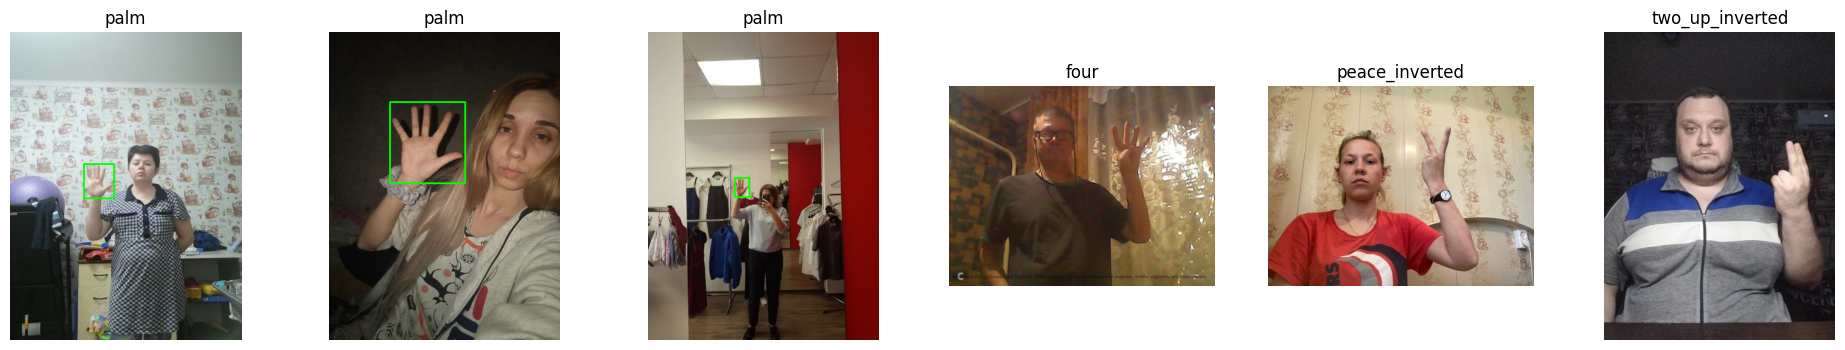

In [ ]:
import cv2
import matplotlib.pyplot as plt

def show_samples(split='train', n_pos=3, n_neg=3):
    imgs = sorted(glob.glob(f'{dataset_root}/images/{split}/*'))
    lbl = lambda p: f'{dataset_root}/labels/{split}/' + os.path.splitext(os.path.basename(p))[0] + '.txt'
    pos = [p for p in imgs if os.path.getsize(lbl(p)) > 0]
    neg = [p for p in imgs if os.path.getsize(lbl(p)) == 0]
    picks = random.sample(pos, min(n_pos, len(pos))) + random.sample(neg, min(n_neg, len(neg)))

    plt.figure(figsize=(4 * len(picks), 4))
    for i, p in enumerate(picks):
        im = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        H, W = im.shape[:2]
        for line in open(lbl(p)).read().split('\n'):
            if not line.strip():
                continue
            _, cx, cy, w, h = map(float, line.split())
            x1, y1 = int((cx - w/2) * W), int((cy - h/2) * H)
            x2, y2 = int((cx + w/2) * W), int((cy + h/2) * H)
            cv2.rectangle(im, (x1, y1), (x2, y2), (0, 255, 0), 2)
        img_id = os.path.splitext(os.path.basename(p))[0]
        plt.subplot(1, len(picks), i + 1)
        plt.imshow(im); plt.axis('off'); plt.title(records[img_id]['cls'])
    plt.show()

show_samples()

## (선택) 만든 데이터셋을 g-drive에 백업

In [ ]:
# 다음 세션에서 변환을 다시 하지 않으려면 주석을 풀고 실행하세요
# shutil.make_archive(f'{save_dir}/HaGRID_Palm_YOLO', 'zip', dataset_root)

## Ultralytics 설치 및 import

In [ ]:
!pip -q install -U ultralytics==8.4.98

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 424.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.7 MB/s eta 0:00:00


## 학습

- `flipud=0.0`: 손을 위아래로 뒤집으면 HaGRID의 `*_inverted` 제스처처럼 보이므로 끕니다.
- `exist_ok=True`: 결과 폴더 이름을 `RUN_NAME`으로 고정해서 아래 `BEST` 경로가 항상 맞게 합니다.

In [ ]:
DATA = f'{dataset_root}/data.yaml'

!yolo detect train model=yolo11n.pt data={DATA} \
  imgsz={IMGSZ} epochs=60 batch=64 device=0 workers=4 \
  project={project_root} name={RUN_NAME} exist_ok=True \
  degrees=15.0 flipud=0.0 fliplr=0.5 mosaic=1.0 patience=20

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.4.163 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.98 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/HaGRID_Palm_YOLO/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=6

## 오탐 확인 (negative val 이미지에서 palm이 잘못 검출되는지)

*   항목 추가
*   항목 추가



mAP만 보면 오탐이 잘 드러나지 않으므로, palm이 없는 val 이미지에서 몇 장에 palm 박스가 나오는지 클래스별로 셉니다.

In [ ]:
from ultralytics import YOLO

BEST = f'{project_root}/{RUN_NAME}/weights/best.pt'
model = YOLO(BEST)

CONF = 0.5
val_imgs = sorted(glob.glob(f'{dataset_root}/images/val/*'))
neg_imgs = [p for p in val_imgs
            if os.path.getsize(f'{dataset_root}/labels/val/' + os.path.splitext(os.path.basename(p))[0] + '.txt') == 0]

total, fp = Counter(), Counter()
for r in model.predict(neg_imgs, imgsz=IMGSZ, conf=CONF, stream=True, verbose=False):
    cls = records[os.path.splitext(os.path.basename(r.path))[0]]['cls']
    total[cls] += 1
    fp[cls] += int(len(r.boxes) > 0)

print(f'conf={CONF} 기준 palm 오탐 (negative 이미지 중 palm이 검출된 비율)')
for c in sorted(total, key=lambda c: -fp[c] / total[c]):
    print(f'  {c:16s} {fp[c]:4d} / {total[c]:4d}  ({fp[c]/total[c]:.1%})')
print(f'  {"전체":16s} {sum(fp.values()):4d} / {sum(total.values()):4d}')

FileNotFoundError: [Errno 2] No such file or directory: '/content/palm_runs/palm_yolo11n/weights/best.pt'

## LiteRT로 변환

In [ ]:
# 양자화 안함
!yolo export model={BEST} format=litert imgsz={IMGSZ} data={DATA}

In [ ]:
# PTQ(INT8) (입력과 출력은 float32)
!yolo export model={BEST} format=litert imgsz={IMGSZ} data={DATA} quantize=8

In [ ]:
# PTQ(Dynamic Range)
!yolo export model={BEST} format=litert imgsz={IMGSZ} data={DATA} quantize=w8a32

## tflite 파일 저장

In [ ]:
# 내보내기 결과가 weights 폴더 아래 하위 폴더에 생기는 경우도 있어서 find로 모두 찾아 복사합니다
!find {project_root}/{RUN_NAME}/weights -name "*.tflite" -print -exec cp {{}} {save_dir} \;